In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

flights = pd.read_csv("data/flights.csv")

flights.head

/var/folders/z_/x2pbw00x521fmpfr6_6w3j5m0000gn/T/ipykernel_5480/206680910.py:5: DtypeWarning: Columns (7: ORIGIN_AIRPORT, 8: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv("data/flights.csv")


<bound method NDFrame.head of          YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0        2015      1    1            4      AS             98      N407AS   
1        2015      1    1            4      AA           2336      N3KUAA   
2        2015      1    1            4      US            840      N171US   
3        2015      1    1            4      AA            258      N3HYAA   
4        2015      1    1            4      AS            135      N527AS   
...       ...    ...  ...          ...     ...            ...         ...   
5819074  2015     12   31            4      B6            688      N657JB   
5819075  2015     12   31            4      B6            745      N828JB   
5819076  2015     12   31            4      B6           1503      N913JB   
5819077  2015     12   31            4      B6            333      N527JB   
5819078  2015     12   31            4      B6            839      N534JB   

        ORIGIN_AIRPORT DESTINATION_AIRPORT  S

In [5]:
flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='str')

In [6]:
flights.shape

(5819079, 31)

In [7]:
flights.isnull().sum()


YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [8]:
missing_percentage = (flights.isnull().sum() / len(flights)) * 100

missing_percentage.sort_values(ascending=False)

CANCELLATION_REASON    98.455357
WEATHER_DELAY          81.724960
LATE_AIRCRAFT_DELAY    81.724960
AIRLINE_DELAY          81.724960
SECURITY_DELAY         81.724960
AIR_SYSTEM_DELAY       81.724960
AIR_TIME                1.805629
ARRIVAL_DELAY           1.805629
ELAPSED_TIME            1.805629
WHEELS_ON               1.589822
TAXI_IN                 1.589822
ARRIVAL_TIME            1.589822
TAXI_OUT                1.530259
WHEELS_OFF              1.530259
DEPARTURE_DELAY         1.480526
DEPARTURE_TIME          1.480526
TAIL_NUMBER             0.252978
SCHEDULED_TIME          0.000103
SCHEDULED_DEPARTURE     0.000000
CANCELLED               0.000000
DAY                     0.000000
DAY_OF_WEEK             0.000000
AIRLINE                 0.000000
FLIGHT_NUMBER           0.000000
SCHEDULED_ARRIVAL       0.000000
DIVERTED                0.000000
ORIGIN_AIRPORT          0.000000
DISTANCE                0.000000
DESTINATION_AIRPORT     0.000000
MONTH                   0.000000
YEAR      

In [9]:
flights["CANCELLED"].value_counts()

CANCELLED
0    5729195
1      89884
Name: count, dtype: int64

In [10]:
flights[flights["CANCELLED"] == 0]["ARRIVAL_DELAY"].describe()

count    5.714008e+06
mean     4.407057e+00
std      3.927130e+01
min     -8.700000e+01
25%     -1.300000e+01
50%     -5.000000e+00
75%      8.000000e+00
max      1.971000e+03
Name: ARRIVAL_DELAY, dtype: float64

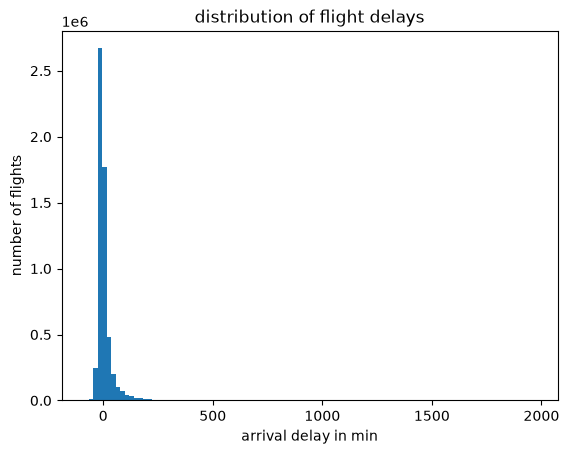

In [17]:
import os
arrival_delay = flights[(flights["CANCELLED"]==0)& (flights["ARRIVAL_DELAY"].notna())]["ARRIVAL_DELAY"]

plt.Figure(figsize=(10,6))

plt.hist(arrival_delay,bins=100)

plt.xlabel("arrival delay in min")
plt.ylabel("number of flights")
plt.title("distribution of flight delays")

plt.savefig("plots/arrival_delay_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

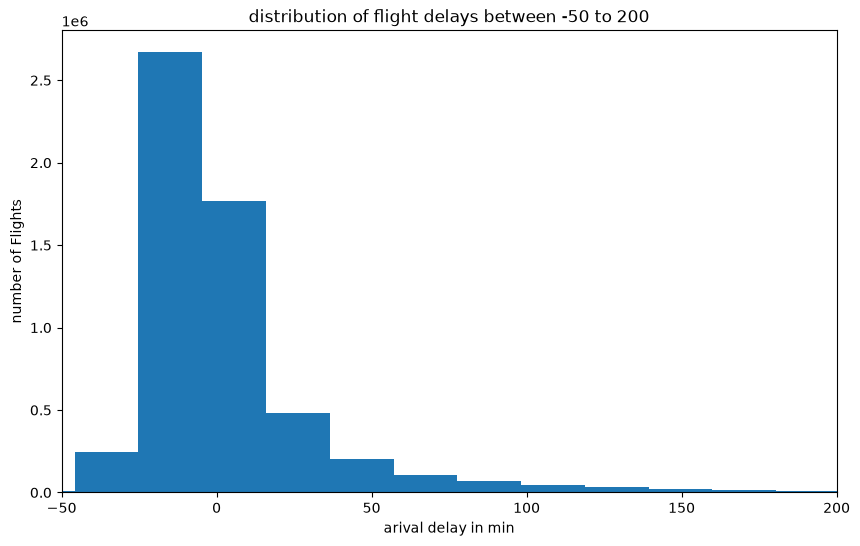

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(arrival_delay, bins=100)

plt.xlim(-50, 200)

plt.xlabel("arival delay in min")
plt.ylabel("number of Flights")
plt.title("distribution of flight delays between -50 to 200")
plt.savefig("plots/arrival_delay_distribution_zoomed.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
delayed_flight = arrival_delay>=15 
delayed_flight.value_counts()

ARRIVAL_DELAY
False    4650569
True     1063439
Name: count, dtype: int64

In [23]:
flights["DELAYED"] = (flights["ARRIVAL_DELAY"]>= 15).astype(int)

flights["DELAYED"].value_counts()

DELAYED
0    4755640
1    1063439
Name: count, dtype: int64

In [24]:
flights = flights[flights["ARRIVAL_DELAY"].notna()]

flights["DELAYED"] = (flights["ARRIVAL_DELAY"] >= 15).astype(int)

flights["DELAYED"].value_counts()

DELAYED
0    4650569
1    1063439
Name: count, dtype: int64

In [25]:
flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DELAYED'],
      dtype='str')

In [26]:
features = [
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "FLIGHT_NUMBER",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_TIME",
    "DISTANCE",
    "SCHEDULED_ARRIVAL"
]

flights[features].isnull().sum()

YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
FLIGHT_NUMBER          0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
SCHEDULED_TIME         0
DISTANCE               0
SCHEDULED_ARRIVAL      0
dtype: int64

In [27]:
X = flights[features]
y = flights["DELAYED"]

print(X.shape)
print(y.shape)

(5714008, 12)
(5714008,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4571206, 12)
(1142802, 12)
(4571206,)
(1142802,)
